<a href="https://colab.research.google.com/github/shreyasat27/molecularspinqubit_computationalpipeline/blob/main/New_molecule_CH(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 52.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


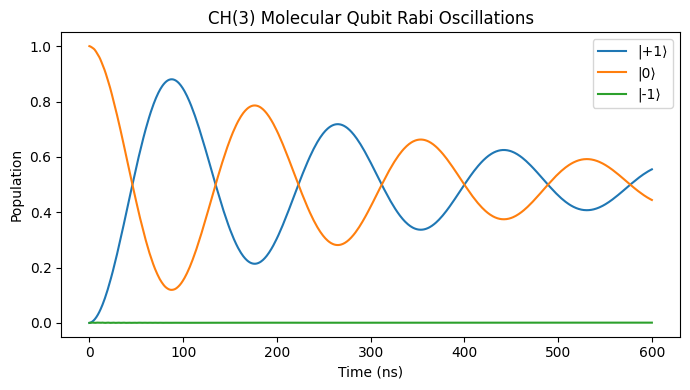

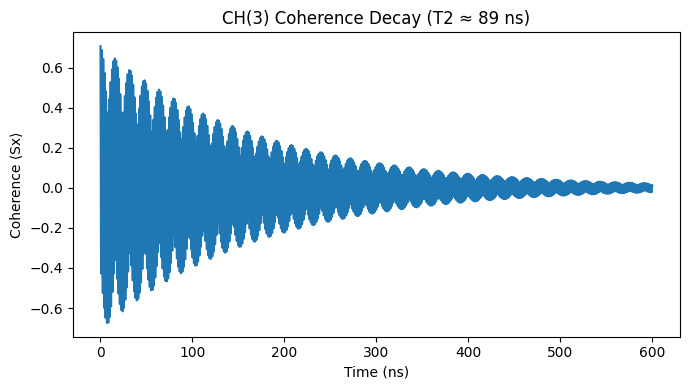

In [3]:
# ================================================================
#  CH(3) TRIPLET MOLECULAR QUBIT SIMULATION
#  Realistic physics model based on experimental paper
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ================================================================
# 1. SPIN-1 TRIPLET OPERATORS
# ================================================================
Sx = spin_Jx(1)
Sy = spin_Jy(1)
Sz = spin_Jz(1)
I3 = qeye(3)

# Basis states
m_plus  = basis(3,0)   # |+1>
m_zero  = basis(3,1)   # |0>
m_minus = basis(3,2)   # |-1>

# ================================================================
# 2. PHYSICAL CONSTANTS
# ================================================================
g = 2.003
mu_B = 9.274e-24
hbar = 1.054e-34

# Static magnetic field (~X-band EPR)
B0 = 0.33  # Tesla

gamma_e = g * mu_B / hbar

# ================================================================
# 3. STATIC HAMILTONIAN (ZEEMAN + ZERO FIELD SPLITTING)
# ================================================================

# Zeeman interaction
H_zeeman = gamma_e * B0 * Sz

# Zero-field splitting parameters (MHz scale for organic triplet)
D = 90e6 * 2*np.pi
E = 15e6 * 2*np.pi

H_ZFS = D * (Sz**2 - 2/3 * I3) + E * (Sx**2 - Sy**2)

# Static Hamiltonian
H_static = H_zeeman + H_ZFS

# ================================================================
# 4. MICROWAVE DRIVE (RABI OSCILLATIONS)
# ================================================================
Omega_R = 8e6 * 2*np.pi  # Rabi frequency (MHz scale)

# Resonant frequency (approximate transition |0> ↔ |+1>)
w0 = gamma_e * B0 + D

def drive_coeff(t, args):
    return np.cos(args['w'] * t)

H = [H_static, [Omega_R * Sx, drive_coeff]]

# ================================================================
# 5. DECOHERENCE (EXPERIMENTAL VALUES FOR CH(3))
# ================================================================
# Experimental coherence times
T1 = 1942e-9     # relaxation
T2 = 89e-9       # dephasing

gamma_relax = 1 / T1
gamma_phi = 1 / T2 - 1 / (2 * T1)

# Relaxation cascade |+1> → |0> → |-1>
c_relax = np.sqrt(gamma_relax) * destroy(3)

# Pure dephasing
c_dephase = np.sqrt(gamma_phi) * Sz

c_ops = [c_relax, c_dephase]

# ================================================================
# 6. INITIAL STATE (PREPARE |0>)
# ================================================================
psi0 = m_zero

# ================================================================
# 7. TIME EVOLUTION
# ================================================================
tlist = np.linspace(0, 600e-9, 1200)

args = {'w': w0}

result = mesolve(
    H,
    psi0,
    tlist,
    c_ops,
    [m_plus*m_plus.dag(), m_zero*m_zero.dag(), m_minus*m_minus.dag()],
    args=args
)

P_plus, P_zero, P_minus = result.expect

# ================================================================
# 8. PLOT RABI OSCILLATIONS
# ================================================================
plt.figure(figsize=(7,4))
plt.plot(tlist*1e9, P_plus, label="|+1⟩")
plt.plot(tlist*1e9, P_zero, label="|0⟩")
plt.plot(tlist*1e9, P_minus, label="|-1⟩")
plt.xlabel("Time (ns)")
plt.ylabel("Population")
plt.title("CH(3) Molecular Qubit Rabi Oscillations")
plt.legend()
plt.tight_layout()
plt.show()

# ================================================================
# 9. COHERENCE DECAY (RAMSEY TYPE)
# ================================================================
rho0 = ket2dm(m_zero + m_plus).unit()

coh = mesolve(
    H_static,
    rho0,
    tlist,
    c_ops,
    [Sx]
)

plt.figure(figsize=(7,4))
plt.plot(tlist*1e9, coh.expect[0])
plt.xlabel("Time (ns)")
plt.ylabel("Coherence ⟨Sx⟩")
plt.title("CH(3) Coherence Decay (T2 ≈ 89 ns)")
plt.tight_layout()
plt.show()
